# Generate and evaluate our naïve one-step-ahead demand forecast.

In [1]:
import pandas as pd
from pathlib import Path

from data.loader import load_raw_m5_data
from data.pipeline import build_item_store_day

RAW_DATA_PATH = Path("../data/raw")

In [2]:
item_store_day = build_item_store_day(*load_raw_m5_data(RAW_DATA_PATH))

In [3]:
item_store_day.columns

Index(['item_id', 'store_id', 'd', 'date', 'wm_yr_wk', 'units_sold',
       'sell_price', 'daily_revenue'],
      dtype='object')

In [4]:
forecasting_baseline = item_store_day[["item_id", "store_id", "d", "date", "units_sold"]].copy()

In [5]:
forecasting_baseline["predicted_units_sold"] = (
    forecasting_baseline
    .groupby(["item_id", "store_id"])["units_sold"]
    .shift(1)
)

In [6]:
forecasting_baseline[
    (forecasting_baseline["item_id"] == "HOBBIES_1_001")
    & (forecasting_baseline["store_id"] == "CA_1")
]

,item_id,store_id,d,date,units_sold,predicted_units_sold
0,HOBBIES_1_001,CA_1,1,2011-01-29,0,NaN
30490,HOBBIES_1_001,CA_1,2,2011-01-30,0,0.0
60980,HOBBIES_1_001,CA_1,3,2011-01-31,0,0.0
91470,HOBBIES_1_001,CA_1,4,2011-02-01,0,0.0
121960,HOBBIES_1_001,CA_1,5,2011-02-02,0,0.0
...,...,...,...,...,...,...
58174920,HOBBIES_1_001,CA_1,1909,2016-04-20,1,1.0
58205410,HOBBIES_1_001,CA_1,1910,2016-04-21,3,1.0
58235900,HOBBIES_1_001,CA_1,1911,2016-04-22,0,3.0
58266390,HOBBIES_1_001,CA_1,1912,2016-04-23,1,0.0


In [7]:
# Check 365-day evaluation period
# 1913 - 165 + 1 = 1549
evaluation = forecasting_baseline[
    forecasting_baseline["d"] >= 1549
].copy()

Quick validation on the slice

In [8]:

evaluation["d"].nunique()

365

In [9]:
evaluation["d"].agg(["min", "max"])

min    1549
max    1913
Name: d, dtype: int64

Calculate MAE

In [10]:
evaluation["error_abs"] = abs(evaluation["predicted_units_sold"] - evaluation["units_sold"])

In [11]:
evaluation["error_abs"].mean()

np.float64(1.110958544683413)

In [12]:
from sklearn.metrics import mean_absolute_error

In [13]:
mean_absolute_error(
    evaluation["units_sold"],
    evaluation["predicted_units_sold"]
)

1.110958544683413

In [14]:
evaluation["error_abs"].mean() == mean_absolute_error(
    evaluation["units_sold"],
    evaluation["predicted_units_sold"]
)

np.True_

In [15]:
evaluation["error_abs_squared"] = evaluation["error_abs"] ** 2
rmse = ((evaluation["error_abs_squared"].sum()) / len(evaluation)) ** 0.5
print(rmse)

2.6438556727619287


In [16]:
from sklearn.metrics import root_mean_squared_error

In [17]:
root_mean_squared_error(
    evaluation["units_sold"],
    evaluation["predicted_units_sold"]
)

2.6438556727619287

In [18]:
rmse == root_mean_squared_error(
    evaluation["units_sold"],
    evaluation["predicted_units_sold"]
)

np.True_

In [19]:
del rmse

In [20]:
mean_units_sold = evaluation["units_sold"].mean()

In [21]:
mean_units_sold = evaluation["units_sold"].mean()
n = len(evaluation)
# Sample SD
standard_deviation = (
    ((evaluation["units_sold"] - mean_units_sold) ** 2).sum() / (n - 1)
) ** 0.5
standard_deviation

np.float64(3.615821538811303)

In [22]:
evaluation["units_sold"].std()

np.float64(3.615821538811303)

In [23]:
standard_deviation = evaluation["units_sold"].std()

In [24]:
del standard_deviation, mean_units_sold, n

In [25]:
evaluation.drop("error_abs_squared", axis=1, inplace=True)

In [26]:
evaluation.head()

,item_id,store_id,d,date,units_sold,predicted_units_sold,error_abs
47198520,HOBBIES_1_001,CA_1,1549,2015-04-26,0,2.0,2.0
47198521,HOBBIES_1_002,CA_1,1549,2015-04-26,0,0.0,0.0
47198522,HOBBIES_1_003,CA_1,1549,2015-04-26,0,0.0,0.0
47198523,HOBBIES_1_004,CA_1,1549,2015-04-26,3,2.0,1.0
47198524,HOBBIES_1_005,CA_1,1549,2015-04-26,0,2.0,2.0


In [27]:
mean_units_sold = evaluation.groupby(["item_id", "store_id"])["units_sold"].mean().reset_index()
mean_units_sold.rename(columns = {"units_sold": "mean_demand"}, inplace=True)

In [28]:
mean_units_sold.head()

,item_id,store_id,mean_demand
0,FOODS_1_001,CA_1,0.673973
1,FOODS_1_001,CA_2,0.980822
2,FOODS_1_001,CA_3,0.978082
3,FOODS_1_001,CA_4,0.306849
4,FOODS_1_001,TX_1,0.534247


In [29]:
pd.merge(
    evaluation,
    mean_units_sold,
    how="left",
    on=["item_id", "store_id"],
    validate="many_to_one"
)

,item_id,store_id,d,date,units_sold,predicted_units_sold,error_abs,mean_demand
0,HOBBIES_1_001,CA_1,1549,2015-04-26,0,2.0,2.0,0.679452
1,HOBBIES_1_002,CA_1,1549,2015-04-26,0,0.0,0.0,0.353425
2,HOBBIES_1_003,CA_1,1549,2015-04-26,0,0.0,0.0,0.534247
3,HOBBIES_1_004,CA_1,1549,2015-04-26,3,2.0,1.0,1.964384
4,HOBBIES_1_005,CA_1,1549,2015-04-26,0,2.0,2.0,1.128767
...,...,...,...,...,...,...,...,...
11128845,FOODS_3_823,WI_3,1913,2016-04-24,1,0.0,1.0,0.580822
11128846,FOODS_3_824,WI_3,1913,2016-04-24,0,1.0,1.0,0.024658
11128847,FOODS_3_825,WI_3,1913,2016-04-24,0,1.0,1.0,0.635616
11128848,FOODS_3_826,WI_3,1913,2016-04-24,3,1.0,2.0,1.082192


In [30]:
evaluation.head()

,item_id,store_id,d,date,units_sold,predicted_units_sold,error_abs
47198520,HOBBIES_1_001,CA_1,1549,2015-04-26,0,2.0,2.0
47198521,HOBBIES_1_002,CA_1,1549,2015-04-26,0,0.0,0.0
47198522,HOBBIES_1_003,CA_1,1549,2015-04-26,0,0.0,0.0
47198523,HOBBIES_1_004,CA_1,1549,2015-04-26,3,2.0,1.0
47198524,HOBBIES_1_005,CA_1,1549,2015-04-26,0,2.0,2.0


In [31]:
# Simpler than above
item_store_summary = (
    evaluation
    .groupby(["item_id", "store_id"])
    .agg(
        mean_demand=("units_sold", "mean"),
        demand_sd=("units_sold", "std"),
        demand_mae=("error_abs", "mean"),
    )
    .reset_index()
)

In [32]:
evaluation.head()

,item_id,store_id,d,date,units_sold,predicted_units_sold,error_abs
47198520,HOBBIES_1_001,CA_1,1549,2015-04-26,0,2.0,2.0
47198521,HOBBIES_1_002,CA_1,1549,2015-04-26,0,0.0,0.0
47198522,HOBBIES_1_003,CA_1,1549,2015-04-26,0,0.0,0.0
47198523,HOBBIES_1_004,CA_1,1549,2015-04-26,3,2.0,1.0
47198524,HOBBIES_1_005,CA_1,1549,2015-04-26,0,2.0,2.0


In [33]:
item_store_summary.head()

,item_id,store_id,mean_demand,demand_sd,demand_mae
0,FOODS_1_001,CA_1,0.673973,1.013918,1.013699
1,FOODS_1_001,CA_2,0.980822,1.674687,1.364384
2,FOODS_1_001,CA_3,0.978082,2.382298,1.558904
3,FOODS_1_001,CA_4,0.306849,0.733112,0.523288
4,FOODS_1_001,TX_1,0.534247,1.700696,0.876712


In [34]:

root_mean_squared_error(
    evaluation["units_sold"],
    evaluation["predicted_units_sold"],
)

2.6438556727619287

In [35]:
rmse_df = (
    evaluation
    .groupby(["item_id", "store_id"])[["units_sold", "predicted_units_sold"]]
    .apply(
        lambda group: root_mean_squared_error(
            group["units_sold"],
            group["predicted_units_sold"],
        )
    )
    .rename("demand_rmse")
    .reset_index()
)

In [36]:
evaluation.head()

,item_id,store_id,d,date,units_sold,predicted_units_sold,error_abs
47198520,HOBBIES_1_001,CA_1,1549,2015-04-26,0,2.0,2.0
47198521,HOBBIES_1_002,CA_1,1549,2015-04-26,0,0.0,0.0
47198522,HOBBIES_1_003,CA_1,1549,2015-04-26,0,0.0,0.0
47198523,HOBBIES_1_004,CA_1,1549,2015-04-26,3,2.0,1.0
47198524,HOBBIES_1_005,CA_1,1549,2015-04-26,0,2.0,2.0


In [37]:
item_store_summary.head()

,item_id,store_id,mean_demand,demand_sd,demand_mae
0,FOODS_1_001,CA_1,0.673973,1.013918,1.013699
1,FOODS_1_001,CA_2,0.980822,1.674687,1.364384
2,FOODS_1_001,CA_3,0.978082,2.382298,1.558904
3,FOODS_1_001,CA_4,0.306849,0.733112,0.523288
4,FOODS_1_001,TX_1,0.534247,1.700696,0.876712


In [38]:
rmse_df.head()

,item_id,store_id,demand_rmse
0,FOODS_1_001,CA_1,1.498858
1,FOODS_1_001,CA_2,2.398630
2,FOODS_1_001,CA_3,3.382874
3,FOODS_1_001,CA_4,1.058559
4,FOODS_1_001,TX_1,2.416836


In [39]:
item_store_summary = pd.merge(
    item_store_summary,
    rmse_df,
    on=["item_id", "store_id"],
    validate="one_to_one"
)

In [40]:
item_store_summary.head()

,item_id,store_id,mean_demand,demand_sd,demand_mae,demand_rmse
0,FOODS_1_001,CA_1,0.673973,1.013918,1.013699,1.498858
1,FOODS_1_001,CA_2,0.980822,1.674687,1.364384,2.398630
2,FOODS_1_001,CA_3,0.978082,2.382298,1.558904,3.382874
3,FOODS_1_001,CA_4,0.306849,0.733112,0.523288,1.058559
4,FOODS_1_001,TX_1,0.534247,1.700696,0.876712,2.416836


In [41]:
item_store_summary.describe()

,mean_demand,demand_sd,demand_mae,demand_rmse
count,30490.000000,30490.000000,30490.000000,30490.000000
mean,1.292957,1.420019,1.110959,1.757983
std,2.757414,1.862732,1.341915,1.974739
min,0.000000,0.000000,0.000000,0.000000
25%,0.252055,0.570398,0.391781,0.779884
50%,0.572603,0.922636,0.745205,1.234215
75%,1.293151,1.536871,1.331507,1.990216
max,96.657534,59.965654,44.038356,60.653880


In [42]:
import matplotlib.pyplot as plt

In [43]:
item_store_summary["mean_demand"].quantile(0.95)

np.float64(4.676986301369859)

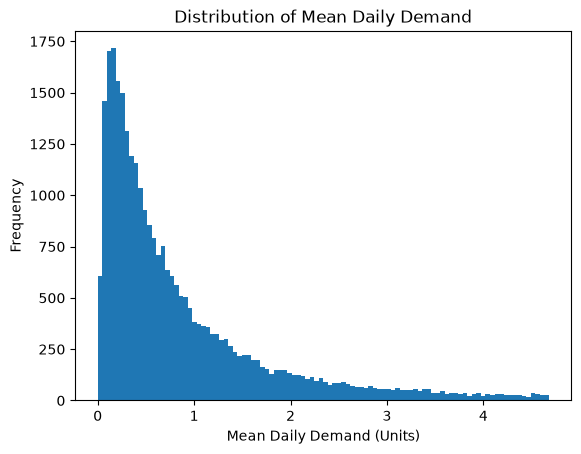

In [44]:
plt.hist(
    item_store_summary["mean_demand"],
    range=(0, item_store_summary["mean_demand"].quantile(0.95)),
    bins=100,
)

plt.xlabel("Mean Daily Demand (Units)")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Daily Demand");

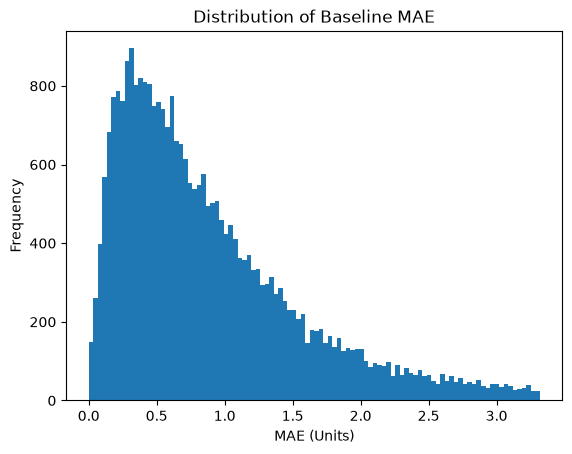

In [45]:
plt.hist(
    item_store_summary["demand_mae"],
    range=(0, item_store_summary["demand_mae"].quantile(0.95)),
    bins=100,
)

plt.xlabel("MAE (Units)")
plt.ylabel("Frequency")
plt.title("Distribution of Baseline MAE");

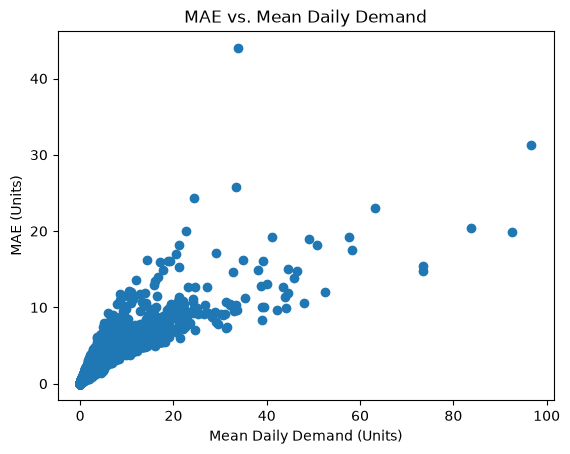

In [46]:
plt.scatter(
    item_store_summary["mean_demand"],
    item_store_summary["demand_mae"],
)

plt.xlabel("Mean Daily Demand (Units)")
plt.ylabel("MAE (Units)")
plt.title("MAE vs. Mean Daily Demand");

In [47]:
item_store_summary

,item_id,store_id,mean_demand,demand_sd,demand_mae,demand_rmse
0,FOODS_1_001,CA_1,0.673973,1.013918,1.013699,1.498858
1,FOODS_1_001,CA_2,0.980822,1.674687,1.364384,2.398630
2,FOODS_1_001,CA_3,0.978082,2.382298,1.558904,3.382874
3,FOODS_1_001,CA_4,0.306849,0.733112,0.523288,1.058559
4,FOODS_1_001,TX_1,0.534247,1.700696,0.876712,2.416836
...,...,...,...,...,...,...
30485,HOUSEHOLD_2_516,TX_2,0.312329,0.565478,0.465753,0.804099
30486,HOUSEHOLD_2_516,TX_3,0.186301,0.410479,0.295890,0.558864
30487,HOUSEHOLD_2_516,WI_1,0.054795,0.239643,0.109589,0.347200
30488,HOUSEHOLD_2_516,WI_2,0.052055,0.234468,0.104110,0.339217


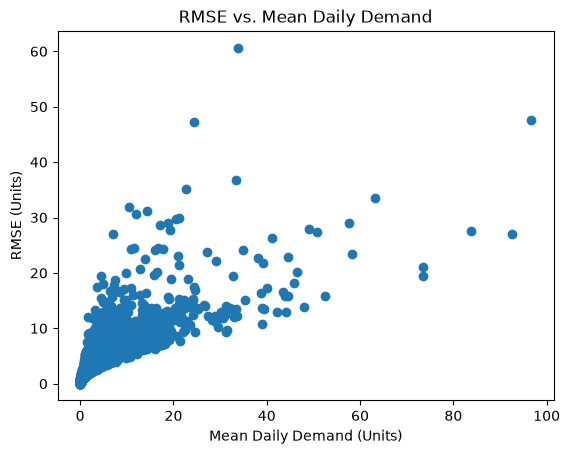

In [48]:
plt.scatter(
    item_store_summary["mean_demand"],
    item_store_summary["demand_rmse"],
)

plt.xlabel("Mean Daily Demand (Units)")
plt.ylabel("RMSE (Units)")
plt.title("RMSE vs. Mean Daily Demand");

In [49]:
item_store_summary

,item_id,store_id,mean_demand,demand_sd,demand_mae,demand_rmse
0,FOODS_1_001,CA_1,0.673973,1.013918,1.013699,1.498858
1,FOODS_1_001,CA_2,0.980822,1.674687,1.364384,2.398630
2,FOODS_1_001,CA_3,0.978082,2.382298,1.558904,3.382874
3,FOODS_1_001,CA_4,0.306849,0.733112,0.523288,1.058559
4,FOODS_1_001,TX_1,0.534247,1.700696,0.876712,2.416836
...,...,...,...,...,...,...
30485,HOUSEHOLD_2_516,TX_2,0.312329,0.565478,0.465753,0.804099
30486,HOUSEHOLD_2_516,TX_3,0.186301,0.410479,0.295890,0.558864
30487,HOUSEHOLD_2_516,WI_1,0.054795,0.239643,0.109589,0.347200
30488,HOUSEHOLD_2_516,WI_2,0.052055,0.234468,0.104110,0.339217


In [50]:
item_store_summary["mae_rel"] = item_store_summary["demand_mae"] / item_store_summary["mean_demand"]

In [51]:
item_store_summary

,item_id,store_id,mean_demand,demand_sd,demand_mae,demand_rmse,mae_rel
0,FOODS_1_001,CA_1,0.673973,1.013918,1.013699,1.498858,1.504065
1,FOODS_1_001,CA_2,0.980822,1.674687,1.364384,2.398630,1.391061
2,FOODS_1_001,CA_3,0.978082,2.382298,1.558904,3.382874,1.593838
3,FOODS_1_001,CA_4,0.306849,0.733112,0.523288,1.058559,1.705357
4,FOODS_1_001,TX_1,0.534247,1.700696,0.876712,2.416836,1.641026
...,...,...,...,...,...,...,...
30485,HOUSEHOLD_2_516,TX_2,0.312329,0.565478,0.465753,0.804099,1.491228
30486,HOUSEHOLD_2_516,TX_3,0.186301,0.410479,0.295890,0.558864,1.588235
30487,HOUSEHOLD_2_516,WI_1,0.054795,0.239643,0.109589,0.347200,2.000000
30488,HOUSEHOLD_2_516,WI_2,0.052055,0.234468,0.104110,0.339217,2.000000


In [52]:
item_store_summary.describe()

,mean_demand,demand_sd,demand_mae,demand_rmse,mae_rel
count,30490.000000,30490.000000,30490.000000,30490.000000,30456.000000
mean,1.292957,1.420019,1.110959,1.757983,1.293088
std,2.757414,1.862732,1.341915,1.974739,0.373435
min,0.000000,0.000000,0.000000,0.000000,0.201437
25%,0.252055,0.570398,0.391781,0.779884,1.019716
50%,0.572603,0.922636,0.745205,1.234215,1.313849
75%,1.293151,1.536871,1.331507,1.990216,1.589147
max,96.657534,59.965654,44.038356,60.653880,2.250000


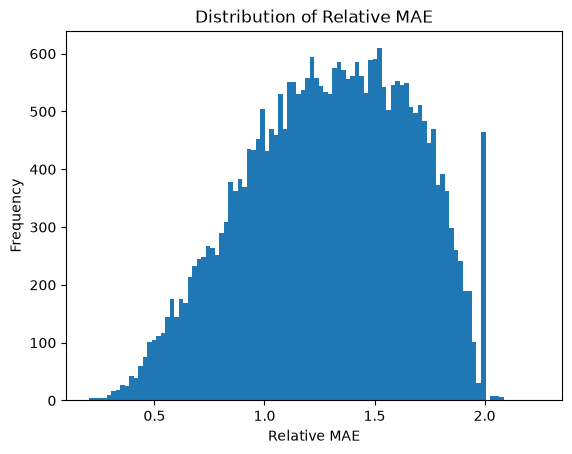

In [53]:
plt.hist(
    item_store_summary["mae_rel"],
    bins=100,
)
plt.xlabel("Relative MAE")
plt.ylabel("Frequency")
plt.title("Distribution of Relative MAE");

In [54]:
item_store_summary[item_store_summary["mae_rel"] == 2][["item_id", "store_id"]]

,item_id,store_id
313,FOODS_1_033,CA_4
770,FOODS_1_079,CA_1
771,FOODS_1_079,CA_2
772,FOODS_1_079,CA_3
773,FOODS_1_079,CA_4
...,...,...
30409,HOUSEHOLD_2_508,WI_3
30468,HOUSEHOLD_2_514,WI_2
30469,HOUSEHOLD_2_514,WI_3
30487,HOUSEHOLD_2_516,WI_1


In [55]:
item_store_summary[item_store_summary["mae_rel"] == 2].describe()

,mean_demand,demand_sd,demand_mae,demand_rmse,mae_rel
count,464.000000,464.000000,464.000000,464.000000,464.0
mean,0.047874,0.235240,0.095749,0.339593,2.0
std,0.029278,0.112122,0.058555,0.162470,0.0
min,0.002740,0.052342,0.005479,0.074023,2.0
25%,0.027397,0.171199,0.054795,0.245508,2.0
50%,0.043836,0.222442,0.087671,0.322660,2.0
75%,0.065753,0.276813,0.131507,0.400331,2.0
max,0.180822,0.981708,0.361644,1.406443,2.0


In [56]:
evaluation[
    (evaluation["item_id"] == "FOODS_1_033")
    & (evaluation["store_id"] == "CA_4")
    & (evaluation["units_sold"] != 0)
]

,item_id,store_id,d,date,units_sold,predicted_units_sold,error_abs
47971560,FOODS_1_033,CA_4,1574,2015-05-21,1,0.0,1.0
48367930,FOODS_1_033,CA_4,1587,2015-06-03,1,0.0,1.0
49008220,FOODS_1_033,CA_4,1608,2015-06-24,1,0.0,1.0
49191160,FOODS_1_033,CA_4,1614,2015-06-30,1,0.0,1.0
49465570,FOODS_1_033,CA_4,1623,2015-07-09,1,0.0,1.0
49587530,FOODS_1_033,CA_4,1627,2015-07-13,1,0.0,1.0
50532720,FOODS_1_033,CA_4,1658,2015-08-13,1,0.0,1.0
50624190,FOODS_1_033,CA_4,1661,2015-08-16,1,0.0,1.0
51813300,FOODS_1_033,CA_4,1700,2015-09-24,1,0.0,1.0
51996240,FOODS_1_033,CA_4,1706,2015-09-30,1,0.0,1.0


In [57]:
mae_rel_2 = item_store_summary[item_store_summary["mae_rel"] == 2][["item_id", "store_id"]]
mae_rel_2_evaluation = evaluation.merge(
    mae_rel_2,
    on=["item_id", "store_id"],
    how="inner",
    validate="many_to_one"
)

In [58]:
mae_rel_2_evaluation.describe()

,d,date,units_sold,predicted_units_sold,error_abs
count,169360.00000,169360,169360.000000,169360.000000,169360.000000
mean,1731.00000,2015-10-25 00:00:00,0.047874,0.047886,0.095749
min,1549.00000,2015-04-26 00:00:00,0.000000,0.000000,0.000000
25%,1640.00000,2015-07-26 00:00:00,0.000000,0.000000,0.000000
50%,1731.00000,2015-10-25 00:00:00,0.000000,0.000000,0.000000
75%,1822.00000,2016-01-24 00:00:00,0.000000,0.000000,0.000000
max,1913.00000,2016-04-24 00:00:00,15.000000,15.000000,15.000000
std,105.36634,NaN,0.261824,0.261867,0.364000


### Finding: Intermittent Demand and Relative MAE

- 464 item-store combinations have a relative MAE of exactly `2.0`.
- These combinations have very low, intermittent demand, with most days having zero sales.
- For an isolated sale, the lag-1 baseline typically makes two errors: it predicts `0` on the sale day, then predicts the previous day's sale on the following zero-sales day.
- This explains why absolute forecast error can equal twice total demand, producing a relative MAE of `2.0`.
- This suggests that a lag-1 baseline performs particularly poorly for intermittent-demand series.

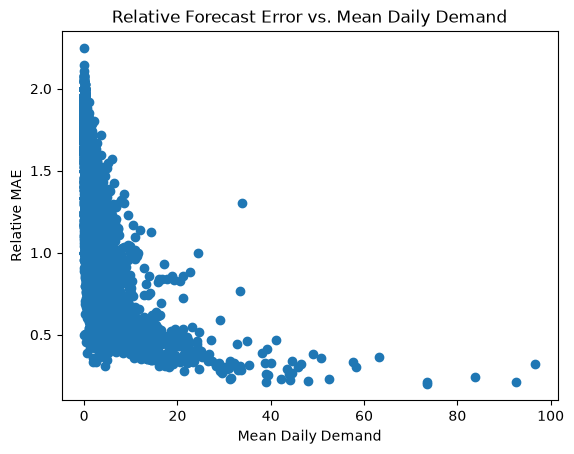

In [59]:
plt.scatter(
    item_store_summary["mean_demand"],
    item_store_summary["mae_rel"],
)
plt.xlabel("Mean Daily Demand")
plt.ylabel("Relative MAE")
plt.title("Relative Forecast Error vs. Mean Daily Demand");

### Relative Forecast Error vs. Mean Demand

- Relative MAE generally decreases as mean daily demand increases.
- The lag-1 baseline performs particularly poorly and inconsistently for low-demand item-store combinations.
- Higher-demand item-store combinations have lower and more tightly clustered relative errors.
- This reinforces the earlier finding that the lag-1 baseline struggles most with low-volume and intermittent demand.

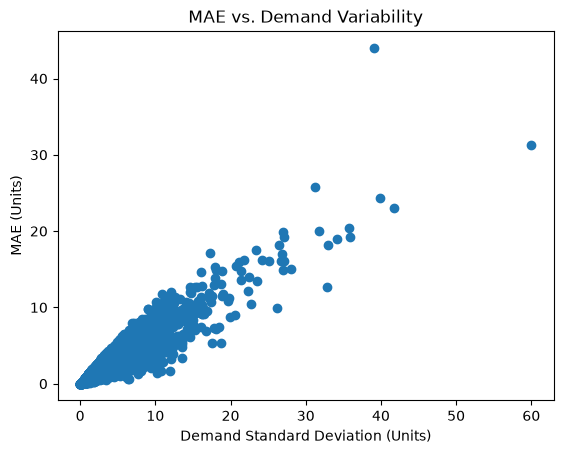

In [60]:
plt.scatter(
    item_store_summary["demand_sd"],
    item_store_summary["demand_mae"],
)

plt.xlabel("Demand Standard Deviation (Units)")
plt.ylabel("MAE (Units)")
plt.title("MAE vs. Demand Variability");

### Forecast Error vs. Demand Variability

- Baseline MAE has a strong, approximately linear relationship with the standard deviation of demand across item-store combinations.
- Item-store combinations with more variable daily demand generally have larger forecast errors.
- This suggests that the lag-1 baseline's performance is strongly related to the underlying variability of each demand series.